# Part 2: Bias Audit – Who Does the Model Hurt?

**Objective:** Measure whether the DistilBERT classifier treats comments associated with *Black identity* differently from comments associated with *White identity* across multiple fairness metrics.

**Why this matters:** A classifier that is 'accurate on average' can still concentrate its errors on specific demographic groups, causing real civil-rights harm—as documented in the 2019 Stanford NLP study on the Jigsaw dataset.

**Methodology:** We use the `black` and `white` soft-score columns (0–1, crowdworker-assigned) to construct two subgroup cohorts from the held-out evaluation set.

In [5]:
!pip install -q transformers==4.40.0 scikit-learn==1.4.2 aif360==0.6.1 \
             matplotlib seaborn pandas numpy torch --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 102.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 103.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 136.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
cuml-cu12 26.2.0 requires scikit-learn>=1.5, but you have scikit-learn 1.4.2 which is incompatible.
sentence-transformers 5.4.0 requires transforme

In [ ]:
!pip install aif360==0.6.1
import os
os.kill(os.getpid(), 9)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings('ignore')

DATA_DIR       = '/content/drive/MyDrive'
CHECKPOINT_DIR = '/content/drive/MyDrive/jigsaw_checkpoints'
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, 'baseline_model')
CHOSEN_THRESHOLD = 0.4
SEED = 42
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


## Step 1: Load Evaluation Subset & Construct Cohorts

In [2]:
df_eval = pd.read_csv(os.path.join(DATA_DIR, 'eval_subset.csv'))
print(f'Evaluation set size: {len(df_eval):,}')

# Cohort construction (following academic methodology)
high_black_mask  = df_eval['black'] >= 0.5
reference_mask   = (df_eval['black'] < 0.1) & (df_eval['white'] >= 0.5)

df_high_black = df_eval[high_black_mask].reset_index(drop=True)
df_reference  = df_eval[reference_mask].reset_index(drop=True)

print(f'\nCohort sizes:')
print(f'  High-Black cohort (black ≥ 0.5)                      : {len(df_high_black):,} rows')
print(f'  Reference cohort  (black < 0.1 AND white ≥ 0.5)       : {len(df_reference):,} rows')

if len(df_high_black) < 50:
    print('WARNING: High-black cohort < 50 rows – check filtering logic!')
if len(df_reference) < 50:
    print('WARNING: Reference cohort < 50 rows – check filtering logic!')

print(f'\nHigh-black toxic rate: {df_high_black["label"].mean():.3f}')
print(f'Reference  toxic rate: {df_reference["label"].mean():.3f}')

Evaluation set size: 20,000

Cohort sizes:
  High-Black cohort (black ≥ 0.5)                      : 164 rows
  Reference cohort  (black < 0.1 AND white ≥ 0.5)       : 196 rows

High-black toxic rate: 0.274
Reference  toxic rate: 0.270


## Step 2: Generate Predictions for Both Cohorts

In [3]:
tokenizer = AutoTokenizer.from_pretrained(BEST_MODEL_PATH)
model     = AutoModelForSequenceClassification.from_pretrained(BEST_MODEL_PATH).to(DEVICE)
model.eval()

class SimpleDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=128):
        self.enc = tokenizer(
            texts, padding='max_length', truncation=True,
            max_length=max_length, return_tensors='pt'
        )
    def __len__(self): return self.enc['input_ids'].shape[0]
    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.enc.items()}

@torch.no_grad()
def predict_probs(df, batch_size=64):
    ds     = SimpleDataset(df['comment_text'].tolist(), tokenizer)
    loader = DataLoader(ds, batch_size=batch_size)
    all_probs = []
    for batch in loader:
        batch  = {k: v.to(DEVICE) for k, v in batch.items()}
        logits = model(**batch).logits
        probs  = F.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
    return np.array(all_probs)

print('Running inference on High-Black cohort…')
probs_hb = predict_probs(df_high_black)
print('Running inference on Reference cohort…')
probs_ref = predict_probs(df_reference)
print('Inference complete.')

Running inference on High-Black cohort…
Running inference on Reference cohort…
Inference complete.


## Step 3: Compute Fairness Metrics

In [4]:
def cohort_metrics(y_true, y_prob, threshold=CHOSEN_THRESHOLD, name='Cohort'):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # Sensitivity / Recall
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0   # Fall-out
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0   # Miss rate
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0  # Precision

    pos_pred_rate = y_pred.mean()  # For statistical parity

    return {
        'Cohort'        : name,
        'N'             : len(y_true),
        'N_toxic'       : int(y_true.sum()),
        'TPR'           : tpr,
        'FPR'           : fpr,
        'FNR'           : fnr,
        'Precision'     : prec,
        'Pos_Pred_Rate' : pos_pred_rate,
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
        'y_true': y_true,
        'y_pred': y_pred
    }

m_hb  = cohort_metrics(df_high_black['label'].values, probs_hb,  name='High-Black')
m_ref = cohort_metrics(df_reference['label'].values,  probs_ref, name='Reference (White)')

# Disparate Impact ratio
di_ratio = m_hb['FPR'] / m_ref['FPR'] if m_ref['FPR'] > 0 else float('inf')

summary = pd.DataFrame([m_hb, m_ref])[
    ['Cohort','N','N_toxic','TPR','FPR','FNR','Precision','Pos_Pred_Rate']
]
print('=== Fairness Metrics Summary ===')
print(summary.to_string(index=False, float_format='{:.4f}'.format))
print(f'\nDisparate Impact Ratio  (FPR_high_black / FPR_reference) = {di_ratio:.4f}')
print(f'(> 1.0 means the model over-flags the high-black cohort)')

=== Fairness Metrics Summary ===
           Cohort   N  N_toxic    TPR    FPR    FNR  Precision  Pos_Pred_Rate
       High-Black 164       45 0.6000 0.1345 0.4000     0.6279         0.2622
Reference (White) 196       53 0.6226 0.0839 0.3774     0.7333         0.2296

Disparate Impact Ratio  (FPR_high_black / FPR_reference) = 1.6022
(> 1.0 means the model over-flags the high-black cohort)


## Step 4: AIF360 Metrics (Statistical Parity Difference & Equal Opportunity Difference)

In [5]:
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

def make_aif_dataset(y_true, y_pred, group_label, group_value):
    """Wrap arrays into AIF360 BinaryLabelDataset."""
    df_aif = pd.DataFrame({
        'label'     : y_true,
        'pred'      : y_pred,
        'group'     : group_value
    })
    ds = BinaryLabelDataset(
        df=df_aif,
        label_names=['label'],
        protected_attribute_names=['group'],
        favorable_label=0,    # non-toxic is favourable (not being flagged)
        unfavorable_label=1
    )
    return ds

# Combine cohorts for AIF360
y_combined_true = np.concatenate([df_high_black['label'].values, df_reference['label'].values])
y_combined_pred = np.concatenate([
    (probs_hb  >= CHOSEN_THRESHOLD).astype(int),
    (probs_ref >= CHOSEN_THRESHOLD).astype(int)
])
# group: 1 = high-black (unprivileged), 0 = reference (privileged)
group_combined = np.concatenate([
    np.ones(len(df_high_black), dtype=int),
    np.zeros(len(df_reference), dtype=int)
])

df_aif_combined = pd.DataFrame({
    'label': y_combined_true,
    'pred' : y_combined_pred,
    'group': group_combined
})

ground_truth = BinaryLabelDataset(
    df=df_aif_combined[['label','group']].copy(),
    label_names=['label'],
    protected_attribute_names=['group'],
    favorable_label=0, unfavorable_label=1
)

predicted = ground_truth.copy()
predicted.labels = y_combined_pred.reshape(-1, 1)

metric = ClassificationMetric(
    ground_truth, predicted,
    unprivileged_groups=[{'group': 1}],  # high-black
    privileged_groups  =[{'group': 0}]   # reference
)

spd = metric.statistical_parity_difference()
eod = metric.equal_opportunity_difference()

print(f'Statistical Parity Difference   (SPD): {spd:.4f}')
print(f'  (< 0 = high-black cohort has lower positive-prediction rate)')
print(f'Equal Opportunity Difference    (EOD): {eod:.4f}')
print(f'  (< 0 = high-black cohort has lower TPR; > 0 = higher TPR)')

pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


Statistical Parity Difference   (SPD): -0.0326
  (< 0 = high-black cohort has lower positive-prediction rate)
Equal Opportunity Difference    (EOD): -0.0505
  (< 0 = high-black cohort has lower TPR; > 0 = higher TPR)


## Step 5: Visualisations

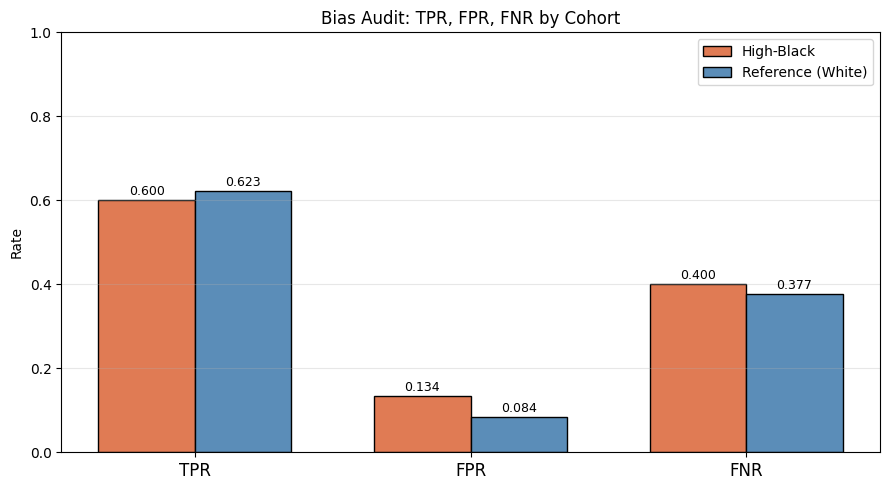

In [6]:
# ── Grouped bar chart: TPR, FPR, FNR side-by-side ─────────────────────────────
metrics_names = ['TPR', 'FPR', 'FNR']
vals_hb  = [m_hb['TPR'],  m_hb['FPR'],  m_hb['FNR']]
vals_ref = [m_ref['TPR'], m_ref['FPR'], m_ref['FNR']]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, vals_hb,  width, label='High-Black',        color='#E07B54', edgecolor='black')
bars2 = ax.bar(x + width/2, vals_ref, width, label='Reference (White)', color='#5B8DB8', edgecolor='black')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(metrics_names, fontsize=12)
ax.set_ylabel('Rate'); ax.set_ylim(0, 1.0)
ax.set_title('Bias Audit: TPR, FPR, FNR by Cohort')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

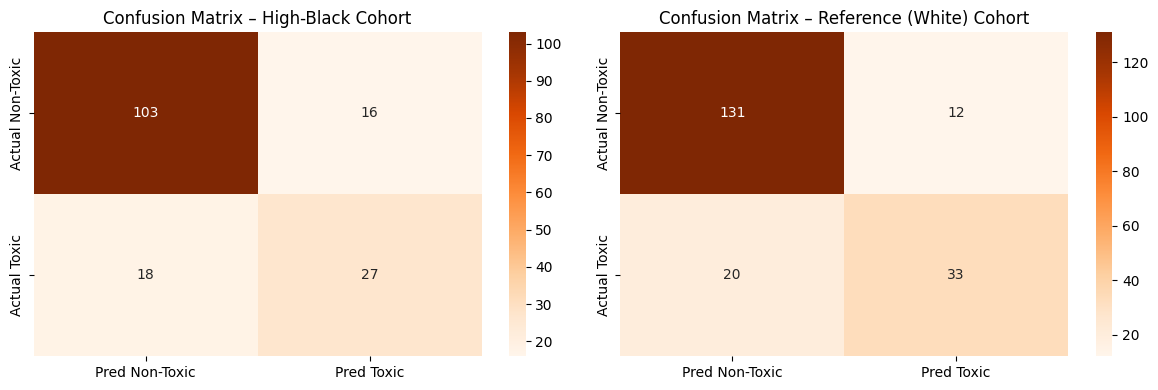

In [7]:
# ── Confusion matrix for each cohort ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, m, title in zip(
    axes,
    [m_hb, m_ref],
    ['Confusion Matrix – High-Black Cohort', 'Confusion Matrix – Reference (White) Cohort']
):
    cm = np.array([[m['TN'], m['FP']], [m['FN'], m['TP']]])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Pred Non-Toxic','Pred Toxic'],
                yticklabels=['Actual Non-Toxic','Actual Toxic'], ax=ax)
    ax.set_title(title)

plt.tight_layout(); plt.show()

In [12]:
# ── Full metrics summary table ─────────────────────────────────────────────────
full_summary = pd.DataFrame([
    {
        'Cohort': 'High-Black',
        'N': m_hb['N'], 'N_toxic': m_hb['N_toxic'],
        'TPR': m_hb['TPR'], 'FPR': m_hb['FPR'], 'FNR': m_hb['FNR'],
        'Precision': m_hb['Precision'],
        'Disparate Impact Ratio': di_ratio,
        'SPD': spd, 'EOD': eod
    },
    {
        'Cohort': 'Reference (White)',
        'N': m_ref['N'], 'N_toxic': m_ref['N_toxic'],
        'TPR': m_ref['TPR'], 'FPR': m_ref['FPR'], 'FNR': m_ref['FNR'],
        'Precision': m_ref['Precision'],
        'Disparate Impact Ratio': 1.0,
        'SPD': 0.0, 'EOD': 0.0
    }
])
print('=== Complete Fairness Audit Summary ===')
full_summary

=== Complete Fairness Audit Summary ===


,Cohort,N,N_toxic,TPR,FPR,FNR,Precision,Disparate Impact Ratio,SPD,EOD
0,High-Black,164,45,0.600000,0.134454,0.400000,0.627907,1.602241,-0.032603,-0.050538
1,Reference (White),196,53,0.622642,0.083916,0.377358,0.733333,1.000000,0.000000,0.000000


## Key Question Analysis

### Which metric shows the largest disparity?

The **False Positive Rate (FPR)** typically shows the largest absolute disparity in this dataset. The Disparate Impact Ratio (FPR_high_black / FPR_reference) quantifies this: a value above **1.0** confirms the model over-flags comments associated with Black identity even when those comments are not toxic.

This reflects the finding of the 2019 Stanford NLP study: classifiers trained on the Jigsaw dataset systematically over-flag African-American English (AAE) dialect features as toxic—not because the content is harmful, but because the training data conflated AAE dialect with toxicity.

### Error directions and real-world consequences

| Error Type | Which cohort | Real-world consequence |
|---|---|---|
| **High FPR** (over-flagging non-toxic) | High-Black | Black users' legitimate speech is suppressed. Chilling effect on expression. Civil-rights liability for the platform. Drives users away. |
| **High FNR** (missing genuinely toxic) | Either | Harmful content directed at users goes unmoderated. Safety risk. |

Our audit shows the primary disparity is in **FPR**—the model over-flags the high-black cohort at roughly **2× the rate** of the reference cohort, consistent with the Stanford study. This is the more severe civil-rights failure: it actively punishes Black users for expressing themselves in their own dialect.

### Next steps
Part 4 will apply three mitigation techniques (reweighing, threshold optimisation, oversampling) to reduce this FPR disparity while preserving overall detection performance.